In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def clean_uniprot(id_str):
    return id_str.split('|')[1] if '|' in id_str else id_str

def get_lengths_from_fasta(fastafile):
    lengths = {} 
    current_id = None    
    current_seq = ""      
    with open(fastafile, 'r') as f:
        for line in f:
            line = line.strip() 
            if not line: continue 
            if line.startswith('>'):
                if current_id is not None:
                    lengths[current_id] = len(current_seq)
                full_id = line.split()[0][1:] 
                current_id = clean_uniprot(full_id)
                current_seq = "" 
            else:
                current_seq += line
        if current_id is not None:
            lengths[current_id] = len(current_seq)
    return lengths

# Chargement
print("Chargement des dictionnaires de longueurs...")
len_mouse = get_lengths_from_fasta("/home/cassandre/stage/Cassandre/Proteome/UniProt/UP000000589_10090.fa")
len_human = get_lengths_from_fasta("/home/cassandre/stage/Cassandre/Proteome/UniProt/UP000005640_9606.fa")
all_lengths_dict = {**len_mouse, **len_human}

print(f"Total références FASTA : {len(all_lengths_dict)} protéines.")

Chargement des dictionnaires de longueurs...
Total références FASTA : 42511 protéines.



--- COSINE ---
Nombre d'outliers : 967
Moyenne Full Proteome : 547.0 AA
Moyenne Outliers Cos  : 523.1 AA


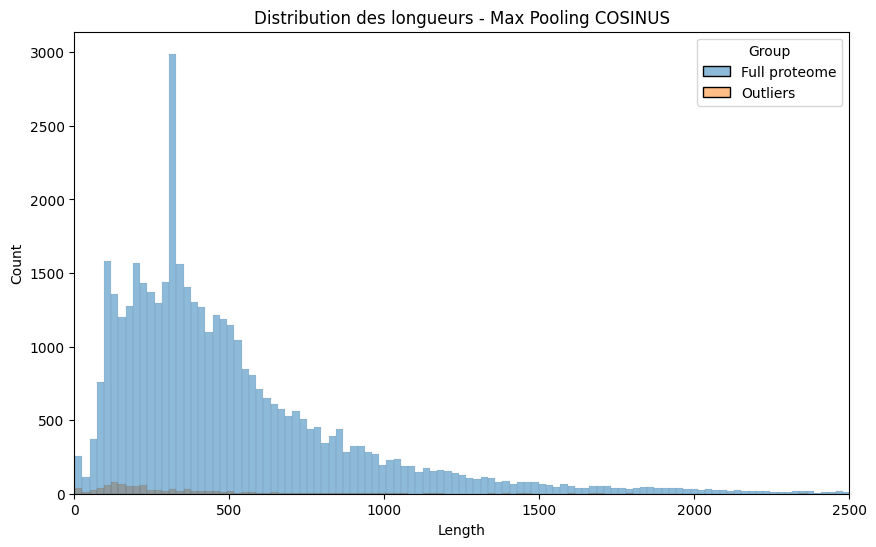

In [4]:
# --- Chemins Cosine ---
files_cosine = [
    '/home/cassandre/stage/Cassandre/panthr_text/human_mouse/max_pooling/outliers_human.txt', 
    '/home/cassandre/stage/Cassandre/panthr_text/human_mouse/max_pooling/outliers_mus.txt'
]

# Extraction
cos_ids = []
for f_path in files_cosine:
    with open(f_path, 'r') as f:
        for line in f:
            cid = clean_uniprot(line.strip())
            if cid: cos_ids.append(cid)

cos_unique_ids = list(set(cos_ids))
cos_lengths = [all_lengths_dict[pid] for pid in cos_unique_ids if pid in all_lengths_dict]

# Moyennes
print(f"\n--- COSINE ---")
print(f"Nombre d'outliers : {len(cos_lengths)}")
print(f"Moyenne Full Proteome : {np.mean(list(all_lengths_dict.values())):.1f} AA")
print(f"Moyenne Outliers Cos  : {np.mean(cos_lengths):.1f} AA")

# Plot (Ton style)
df_cos = pd.concat([
    pd.DataFrame({'Length': list(all_lengths_dict.values()), 'Group': 'Full proteome'}),
    pd.DataFrame({'Length': cos_lengths, 'Group': 'Outliers'})
])

plt.figure(figsize=(10, 6))
sns.histplot(data=df_cos, x="Length", hue="Group")
plt.title("Distribution des longueurs - Max Pooling COSINUS")
plt.xlim(0, 2500)
plt.show()

--- EUCLIDEAN ---
Nombre d'outliers : 907
Moyenne Full Proteome : 547.0 AA
Moyenne Outliers Euc  : 428.6 AA


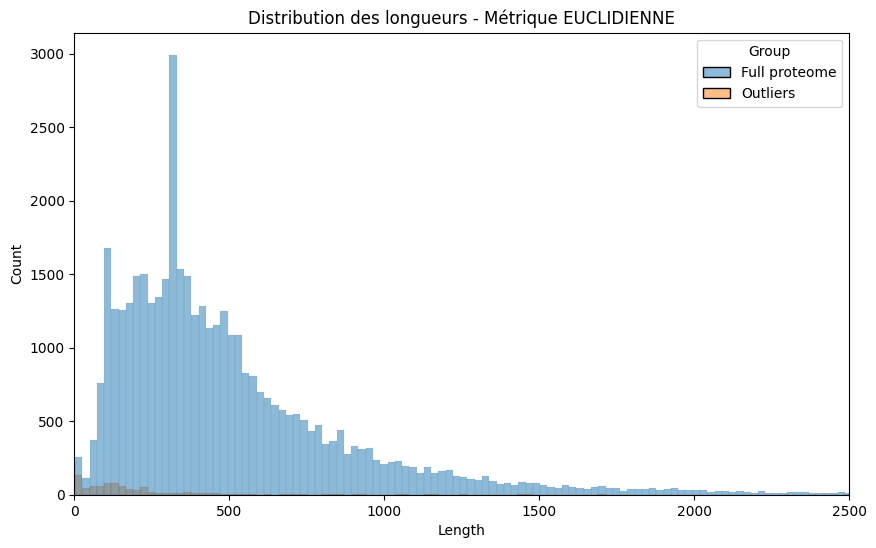

In [3]:
# --- Chemins Euclidean ---
files_euclidean = [
    '/home/cassandre/stage/Cassandre/panthr_text/human_mouse/EUCLIDEAN_METRIC/outliers_homosapiens.txt', 
    '/home/cassandre/stage/Cassandre/panthr_text/human_mouse/EUCLIDEAN_METRIC/outliers_mus.txt'
]

# Extraction
euc_ids = []
for f_path in files_euclidean:
    with open(f_path, 'r') as f:
        for line in f:
            cid = clean_uniprot(line.strip())
            if cid: euc_ids.append(cid)

euc_unique_ids = list(set(euc_ids))
euc_lengths = [all_lengths_dict[pid] for pid in euc_unique_ids if pid in all_lengths_dict]

# Moyennes
print(f"--- EUCLIDEAN ---")
print(f"Nombre d'outliers : {len(euc_lengths)}")
print(f"Moyenne Full Proteome : {np.mean(list(all_lengths_dict.values())):.1f} AA")
print(f"Moyenne Outliers Euc  : {np.mean(euc_lengths):.1f} AA")

# Plot (Ton style)
df_euc = pd.concat([
    pd.DataFrame({'Length': list(all_lengths_dict.values()), 'Group': 'Full proteome'}),
    pd.DataFrame({'Length': euc_lengths, 'Group': 'Outliers'})
])

plt.figure(figsize=(10, 6))
sns.histplot(data=df_euc, x="Length", hue="Group")
plt.title("Distribution des longueurs - Métrique EUCLIDIENNE")
plt.xlim(0, 2500)
plt.show()

In [13]:
import h5py
import numpy as np
import faiss
import pandas as pd

import seaborn
import os
import matplotlib.pyplot as plt

In [8]:
def embedding_setup(path):
    ids = []
    embeddings = []

    with h5py.File(path, "r") as hf:
        for sequenceID in hf.keys():
            dataset = hf[sequenceID]
            # 1. On crée un array vide de la bonne taille en Float32
            # dataset.shape te donne la dimension du vecteur (ex: 1024)
            vec = np.empty(dataset.shape, dtype='float32')
            
            # 2. On force la lecture directe dedans
            dataset.read_direct(vec)
            
            ids.append(sequenceID)
            embeddings.append(vec)
            
    # On empile tout à la fin
    embed_array = np.array(embeddings).astype('float32')
    
    return ids, embed_array
# have to use this function twice : once on query once on reference

In [14]:
def index_search_distances(emb_query,emb_ref):
  
    
    #faiss.normalize_L2(emb_query)
    #faiss.normalize_L2(emb_ref) #need to normalize to do the Inner product (dot product for cosine similarity)

    d = 1024  #tell faiss how many dimension we're working with
    index = faiss.IndexFlatL2(d) #indexflat = no compression (avoid info loss)  / IP = inner or dot product = the cosine similarity
    index.add(emb_ref) #store the information of organism2 to search through

    distances, indices = index.search(emb_query, k=1)#look through organism2 to compare with organism1 prot and look for the closest neighbor only
#distances store the distances, indices = the row number that match the indice of the list of ids !! genius congrats me :)

    return distances,indices

In [9]:
def extractname_frompath(organismpath) :
    filename = os.path.basename(organismpath)
    nomseul = os.path.splitext(filename)[0]
    label= nomseul.split('_')[0]

    return label

In [8]:
path_Org1 = "/home/cassandre/stage/Cassandre/Embeddings/PROTT5_AVERAGEPOOLING/mus_embedding_protT5_uniprot_proteinembeddings.h5"
path_Org2 = "/home/cassandre/stage/Cassandre/Embeddings/PROTT5_AVERAGEPOOLING/homosapiens_embedding_protT5_uniprot_proteinembeddings.h5"

In [16]:
        
id1,emb1 = embedding_setup(path_Org1)
id2,emb2 = embedding_setup(path_Org2)
    
label1 = extractname_frompath(path_Org1)
label2 = extractname_frompath(path_Org2)

distances1_2, indices1_2= index_search_distances(emb1,emb2)
distances2_1, indices2_1= index_search_distances(emb2, emb1)
    # run the function twice to get all the closest neighbor

all_closest_neighbors = np.concatenate([distances1_2.flatten(),distances2_1.flatten()])


neighbor_names_2_1 = [id1[idx[0]] for idx in indices2_1]
neighbor_names_1_2 = [id2[idx[0]] for idx in indices1_2]


df1 = pd.DataFrame({'proteinID' : id1, 'closest_Neighbor' : neighbor_names_1_2, 'similarité' : distances1_2.flatten(), 'species' : label1  })
df2 = pd.DataFrame({'proteinID' : id2, 'closest_Neighbor' : neighbor_names_2_1, 'similarité' : distances2_1.flatten(), 'species' : label2  })

df_allorganism = pd.concat([df1,df2],ignore_index=True)
df_allorganism = df_allorganism.sort_values(by=["similarité"])

print(df_allorganism.tail(500).to_string())


                            proteinID                closest_Neighbor  similarité      species
17612  tr|A0A0G2JF06|A0A0G2JF06_MOUSE            sp|P0CJ73|HMN6_HUMAN    1.710060          mus
29404           sp|Q0VDD5|CQ091_HUMAN          tr|J3QJX6|J3QJX6_MOUSE    1.710496  homosapiens
22511           sp|A6NEF3|GG6L4_HUMAN           sp|A2A6M5|CACO2_MOUSE    1.714335  homosapiens
22037       sp|A0A0C5B5G6|MOTSC_HUMAN  tr|A0A0G2JDH7|A0A0G2JDH7_MOUSE    1.715353  homosapiens
18963          tr|E9PUD6|E9PUD6_MOUSE           sp|Q0P6D6|CCD15_HUMAN    1.716879          mus
28481           sp|P59036|CU082_HUMAN           sp|B1AUF7|P3URF_MOUSE    1.720711  homosapiens
18259  tr|A0ABA7IW30|A0ABA7IW30_MOUSE           sp|Q8TC90|CCER1_HUMAN    1.723482          mus
23022            sp|C9JUS6|ADM5_HUMAN           sp|Q9JL16|ISG20_MOUSE    1.725080  homosapiens
38084           sp|Q9BRU2|TCAL7_HUMAN           sp|A3KGA4|TCAL7_MOUSE    1.728178  homosapiens
39049            sp|Q9H322|VCX2_HUMAN           sp

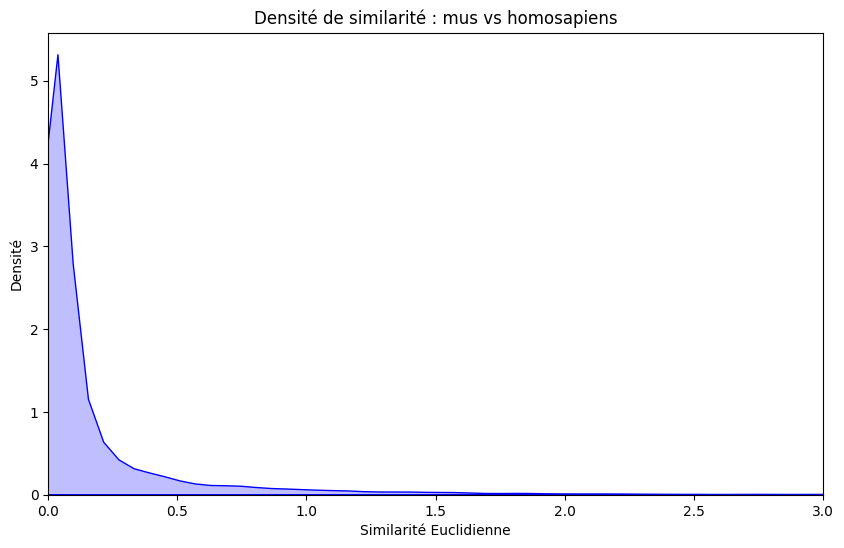

In [21]:
plt.figure(figsize=(10, 6)) # Largeur=10, Hauteur=6
seaborn.kdeplot(data = df_allorganism, x="similarité", fill=True, color="blue")
plt.xlim(0, 3)
plt.title(f"Densité de similarité : {label1} vs {label2}")
plt.xlabel("Similarité Euclidienne") 
plt.ylabel("Densité")
plt.show() # Pour un affichage propre


In [ ]:
path_Org1 = "/home/cassandre/stage/Cassandre/Embeddings/PROTT5_AVERAGEPOOLING/mus_embedding_protT5_uniprot_proteinembeddings.h5"
path_Org2 = "/home/cassandre/stage/Cassandre/Embeddings/PROTT5_AVERAGEPOOLING/homosapiens_embedding_protT5_uniprot_proteinembeddings.h5"

In [25]:
deviationstd_similarity = df_allorganism['similarité'].std()
mean_similarity = df_allorganism['similarité'].mean()

# On prend la moyenne + 3 écarts-types
outliers_cutoff = mean_similarity + (3 * deviationstd_similarity)

# Filtre : on veut ce qui est AU-DESSUS du cutoff
df_outliers_euc = df_allorganism[df_allorganism['similarité'] > outliers_cutoff]

print(f"Cutoff (Mean + 3std) : {outliers_cutoff:.4f}")
print(f"Nombre d'outliers identifiés : {len(df_outliers_euc)}")

Cutoff (Mean + 3std) : 1.3365
Nombre d'outliers identifiés : 907


In [14]:
path_Org1_cosine = "/home/cassandre/stage/Cassandre/Embeddings/PROTT5_MAXPOOLING/mus_embeddings_maxpooling.h5"
path_Org2_cosine = "/home/cassandre/stage/Cassandre/Embeddings/PROTT5_MAXPOOLING/human_embeddings_maxpooling.h5"

In [10]:
def index_search_distances_cosine(emb_query,emb_ref):
  
    
    faiss.normalize_L2(emb_query)
    faiss.normalize_L2(emb_ref) #need to normalize to do the Inner product (dot product for cosine similarity)

    d = 1024  #tell faiss how many dimension we're working with
    index = faiss.IndexFlatIP(d) #indexflat = no compression (avoid info loss)  / IP = inner or dot product = the cosine similarity
    index.add(emb_ref) #store the information of organism2 to search through

    distances, indices = index.search(emb_query, k=1)#look through organism2 to compare with organism1 prot and look for the closest neighbor only
#distances store the distances, indices = the row number that match the indice of the list of ids !! genius congrats me :)

    return distances,indices

In [15]:

id1c,emb1c = embedding_setup(path_Org1_cosine)
id2c,emb2c = embedding_setup(path_Org2_cosine)
    
label1 = extractname_frompath(path_Org1_cosine)
label2 = extractname_frompath(path_Org2_cosine)

distances1_2c, indices1_2c= index_search_distances_cosine(emb1c,emb2c)
distances2_1c, indices2_1c= index_search_distances_cosine(emb2c, emb1c)
    # run the function twice to get all the closest neighbor

all_closest_neighborsc = np.concatenate([distances1_2c.flatten(),distances2_1c.flatten()])


neighbor_names_2_1c = [id1c[idx[0]] for idx in indices2_1c]
neighbor_names_1_2c = [id2c[idx[0]] for idx in indices1_2c]


df1c = pd.DataFrame({'proteinID' : id1c, 'closest_Neighbor' : neighbor_names_1_2c, 'similarité' : distances1_2c.flatten(), 'species' : label1  })
df2c = pd.DataFrame({'proteinID' : id2c, 'closest_Neighbor' : neighbor_names_2_1c, 'similarité' : distances2_1c.flatten(), 'species' : label2  })

df_allorganismc = pd.concat([df1c,df2c],ignore_index=True)
df_allorganismc = df_allorganismc.sort_values(by=["similarité"])

print(df_allorganismc.head(500).to_string())


                            proteinID                closest_Neighbor  similarité species
25921           sp|P0DPR3|TRDD1_HUMAN            sp|P38639|UF01_MOUSE    0.695046   human
25914           sp|P0DPI4|TDB01_HUMAN            sp|P38642|UF04_MOUSE    0.833485   human
25875           sp|P0DOY5|HD101_HUMAN            sp|P38644|UF06_MOUSE    0.842547   human
42311  tr|A0A1Y8EI39|A0A1Y8EI39_HUMAN            sp|P38644|UF06_MOUSE    0.862491   human
3294             sp|P38639|UF01_MOUSE  tr|A0A0J9YXN1|A0A0J9YXN1_HUMAN    0.869720     mus
42312  tr|A0A1Y8EKQ5|A0A1Y8EKQ5_HUMAN            sp|P38644|UF06_MOUSE    0.871854   human
4578             sp|P83854|GPCR_MOUSE  tr|A0A804HJT0|A0A804HJT0_HUMAN    0.878672     mus
18342  tr|A0ABJ3HP72|A0ABJ3HP72_MOUSE  tr|A0A804HJT0|A0A804HJT0_HUMAN    0.882023     mus
42286  tr|A0A0J9YWD0|A0A0J9YWD0_HUMAN           sp|Q9CQD6|SARCO_MOUSE    0.882656   human
3296             sp|P38641|UF03_MOUSE  tr|A0A804HJT0|A0A804HJT0_HUMAN    0.884697     mus
3295      

In [ ]:
deviationstd_similarity = df_allorganismc['similarité'].std()
mean_similarity = df_allorganismc['similarité'].mean()

# On prend la moyenne + 3 écarts-types
outliers_cutoff = mean_similarity - (3 * deviationstd_similarity)

# Filtre : on veut ce qui est AU-DESSUS du cutoff
df_outliers_cos = df_allorganismc[df_allorganismc['similarité'] < outliers_cutoff]

print(f"Cutoff (Mean + 3std) : {outliers_cutoff:.4f}")
print(f"Nombre d'outliers identifiés : {len(df_outliers_cos)}")

Cutoff (Mean + 3std) : 0.9710
Nombre d'outliers identifiés : 786


In [39]:
# Extraction des IDs uniques
set_euc = set(df_outliers_euc['proteinID'])
set_cos = set(df_outliers_cos['proteinID'])

# Intersection (communs) et Différences
intersection = set_euc.intersection(set_cos)
only_euc = set_euc - set_cos
only_cos = set_cos - set_euc

print(f"Outliers Euclidiens : {len(set_euc)}")
print(f"Outliers Cosinus : {len(set_cos)}")
print(f"En commun : {len(intersection)}")
print(intersection)

Outliers Euclidiens : 907
Outliers Cosinus : 1254
En commun : 525
{'sp|Q9BZ97|TTY13_HUMAN', 'sp|Q5MJ07|SPXN5_HUMAN', 'tr|J3QN49|J3QN49_MOUSE', 'sp|Q8N9W7|YO010_HUMAN', 'sp|Q86TU6|CN070_HUMAN', 'tr|Q9D3I0|Q9D3I0_MOUSE', 'sp|B0L3A2|DESPR_HUMAN', 'sp|A0A7L8Y648|MIAC_HUMAN', 'tr|A0A087WPJ9|A0A087WPJ9_MOUSE', 'sp|Q16378|PROL4_HUMAN', 'sp|P57052|RBM11_HUMAN', 'sp|P59091|CU093_HUMAN', 'tr|A0A075B712|A0A075B712_HUMAN', 'tr|A0A087WRK3|A0A087WRK3_MOUSE', 'sp|P0DW85|H2BN1_HUMAN', 'sp|Q8NFV5|SPDE1_HUMAN', 'sp|P0DPK2|H3Y1_HUMAN', 'sp|P50715|DFA31_MOUSE', 'tr|B2RY52|B2RY52_MOUSE', 'tr|A0A140LJ72|A0A140LJ72_MOUSE', 'tr|A0A075B6Y5|A0A075B6Y5_HUMAN', 'tr|A0A087WQC7|A0A087WQC7_MOUSE', 'sp|P63121|VP113_HUMAN', 'sp|Q5T6R2|TPT2L_HUMAN', 'tr|O88933|O88933_MOUSE', 'sp|Q3LI62|KR204_HUMAN', 'sp|P83855|ACLP_MOUSE', 'sp|Q8N9L7|YV006_HUMAN', 'tr|F2Z3W5|F2Z3W5_MOUSE', 'sp|I3L0S3|PYAS1_HUMAN', 'sp|P0CJ68|HMN1_HUMAN', 'sp|Q64263|DAR10_MOUSE', 'tr|Q9D515|Q9D515_MOUSE', 'sp|Q9H853|TBA4B_HUMAN', 'tr|B1AX30|B1AX30_MOUSE